In [1]:
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
# Saving plots with editable text
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts (editable text)

import os
import sys
import logging

In [25]:
adata_infile = "/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/objects/female_adata_stream_input.h5ad"
out_tmp = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/stream_outs'

In [26]:
from os.path import basename
import stream as st
#read the stream result file pkl or h5ad
adata = st.read(file_name=adata_infile, workdir=out_tmp)

Saving results in: /ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/stream_outs


### Plotting cell type specific trajectories

In [27]:
adata_subset = adata[adata.obs['C_scANVI'] == 'Fast IIX']
adata_subset = adata_subset.copy()

In [28]:
adata_subset

AnnData object with n_obs × n_vars = 18524 × 3000
    obs: 'sample_id', 'cell_type', 'condition', 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_mt_cb', 'log1p_total_counts_mt_cb', 'pct_counts_mt_cb', 'total_counts_ribo_cb', 'log1p_total_counts_ribo_cb', 'pct_counts_ribo_cb', 'total_counts_hb_cb', 'log1p_total_counts_hb_cb', 'pct_counts_hb_cb', 'n_genes', 'sex', 'batch', '_scvi_batch', '_scvi_labels', 'C_scANVI'
    var: 'hb', 'ribo', 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'dispersions', 'dispersions_norm', 'n_cells'
    uns: 'C_scANVI_colors', '_scvi_manager_uuid',

In [29]:
# Check if your data is sparse (imputed data is dense, normalized data is sparse)
import scipy.sparse as sp

if sp.issparse(adata_subset.X):
    adata_subset.X = adata_subset.X.toarray()

In [30]:
print(type(adata_subset.X))
print(adata_subset.X.shape)

<class 'numpy.ndarray'>
(18524, 3000)


#### Filter cells if not using imputed data

In [31]:
st.cal_qc(adata_subset,assay='rna')

In [32]:
st.filter_cells(adata_subset,min_n_features= 200, assay='rna')
st.filter_features(adata_subset,min_n_cells = 10, assay='rna')

filter cells based on min_n_features
after filtering out low-quality cells: 
9892 cells, 3000 genes
Filter genes based on min_n_cells
After filtering out low-expressed genes: 
9892 cells, 2212 genes


In [33]:
###Remove mitochondrial genes 
st.remove_mt_genes(adata_subset)

In [34]:
adata_subset.obs['condition'].value_counts()

WT    5435
KO    4457
Name: condition, dtype: int64

In [ ]:
#adata_subset.X = adata_subset.layers['MAGIC_imputed_data']

111 variable genes are selected


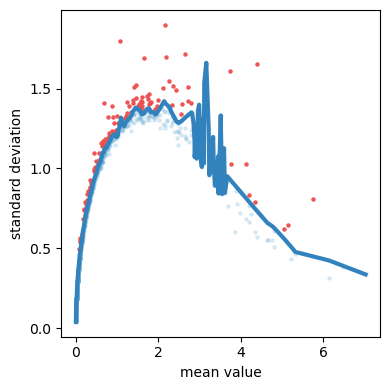

In [12]:
st.select_variable_genes(adata_subset,loess_frac=0.01,percentile=95)

In [35]:
# # 'var_genes' vs 'all' : use top % or all genes from .var ; if using all make sure the adata is subsetted to only the highly variable genes
# # n_components = Number of branches present in your biological differentation (min 2 dimensions for plotting, 3 would make it 3D)
# # method = 'se' or 'mlle' standard LLE or modified LLE
st.dimension_reduction(adata_subset,method='se',feature='all',n_components=2,n_neighbors=30,n_jobs=64) # using the same knn as diffusion maps (default is 30)

feature all is being used ...
64 cpus are being used ...


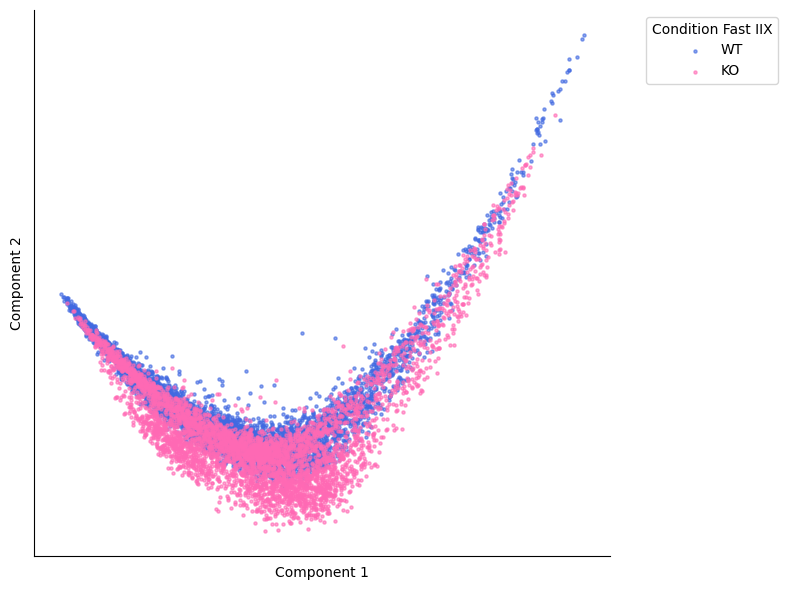

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Color dictionary for conditions
condition_color_dict = {
    'WT': '#4169E1',     # royal blue
    'KO': '#FF69B4'      # hot pink
}

# Ensure condition is categorical
adata_subset.obs['condition'] = pd.Categorical(
    adata_subset.obs['condition'],
    categories=['WT', 'KO'],
    ordered=True
)

# Extract coordinates from the 'X_dr'/'X_mlle' slot 
coords = adata_subset.obsm['X_dr']  # or 'X_mlle'

# Extract the labels for coloring
labels = adata_subset.obs['condition']

# Get unique labels and their corresponding colors
unique_labels = labels.cat.categories  # Use .cat.categories to maintain order
color_list = [condition_color_dict[label] for label in unique_labels]

# Plotting with colors based on condition
plt.figure(figsize=(8, 6))
for label, color in zip(unique_labels, color_list):
    idx = labels == label
    plt.scatter(coords[idx, 0], coords[idx, 1], c=color, label=label, s=5, alpha=0.6)

# Remove ticks
plt.xticks([])
plt.yticks([])

# Remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.title('')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend(title="Condition Fast IIX", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# plt.savefig('/your/path/condition_plot.pdf', 
#             bbox_inches='tight',
#             dpi=300,
#             format='pdf')

plt.show()